In [9]:
import lsdb
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from pathlib import Path

def to_stack(nested_col):
    """Convert a nested-pandas column (7 rows, one per band) into (7, 96, 96)."""
    return np.stack([np.stack(r).astype(np.float32) for r in nested_col.to_list()])

def to_mask_stack(nested_col):
    return np.stack([np.stack(r).astype(bool) for r in nested_col.to_list()])

def pick_populated_band(bands, flux):
    """Return index of first band that isn't all-zero padding."""
    for idx in range(len(bands)):
        if np.any(flux[idx]):
            return idx
    return None  # no real data at all for this object

def get_band_names(image_field):
    return [b.decode() if isinstance(b, (bytes, bytearray)) else str(b)
            for b in image_field["band"].tolist()]

# pull 7 rows
jwst = lsdb.open_catalog("hf://datasets/UniverseTBD/mmu_jwst_ceers")
sample = jwst.head(7)
rows = list(sample.iterrows())
print(f"pulled {len(rows)} rows")

/Users/gaurav/Desktop/Astrobridge/env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Computing Catalog: 100%|██████████| 1/1 [00:08<00:00,  8.38s/it]

pulled 7 rows


In [10]:
out_dir = Path("jwst_masked_flux")
out_dir.mkdir(exist_ok=True)

saved = 0
for _, row in rows:
    image_field = row["image"]
    bands = get_band_names(image_field)
    flux = to_stack(image_field["flux"])
    mask = to_mask_stack(image_field["mask"])

    i = pick_populated_band(bands, flux)
    if i is None:
        print(f"{row['object_id']}: no populated band, skipping")
        continue

    img = flux[i]
    m = mask[i]

    masked_img = np.where(m, img, 0.0)   # zero out pixels where mask is False (bad)

    norm = simple_norm(masked_img, stretch="asinh", percent=99.9)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(masked_img, origin="lower", cmap="gray", norm=norm)
    ax.set_title(f"{row['object_id']} — {bands[i]}", fontsize=9)
    ax.axis("off")
    fig.savefig(out_dir / f"{row['object_id']}_{bands[i]}_maskedflux.png",
                bbox_inches="tight", dpi=120)
    plt.close(fig)
    saved += 1

print(f"saved {saved} masked-flux images to {out_dir}/")

saved 7 masked-flux images to jwst_masked_flux/


In [11]:
out_dir_snr = Path("jwst_snr")
out_dir_snr.mkdir(exist_ok=True)

saved = 0
for _, row in rows:
    image_field = row["image"]
    bands = get_band_names(image_field)
    flux = to_stack(image_field["flux"])
    ivar = to_stack(image_field["ivar"])

    i = pick_populated_band(bands, flux)
    if i is None:
        print(f"{row['object_id']}: no populated band, skipping")
        continue

    img = flux[i]
    iv = ivar[i]
    snr = img * np.sqrt(np.clip(iv, 0, None))

    norm = simple_norm(snr, stretch="asinh", percent=99.5)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(snr, origin="lower", cmap="coolwarm", norm=norm)
    ax.set_title(f"{row['object_id']} — {bands[i]} (peak={snr.max():.1f})", fontsize=9)
    ax.axis("off")
    fig.savefig(out_dir_snr / f"{row['object_id']}_{bands[i]}_snr.png",
                bbox_inches="tight", dpi=120)
    plt.close(fig)
    saved += 1

print(f"saved {saved} SNR images to {out_dir_snr}/")

saved 7 SNR images to jwst_snr/


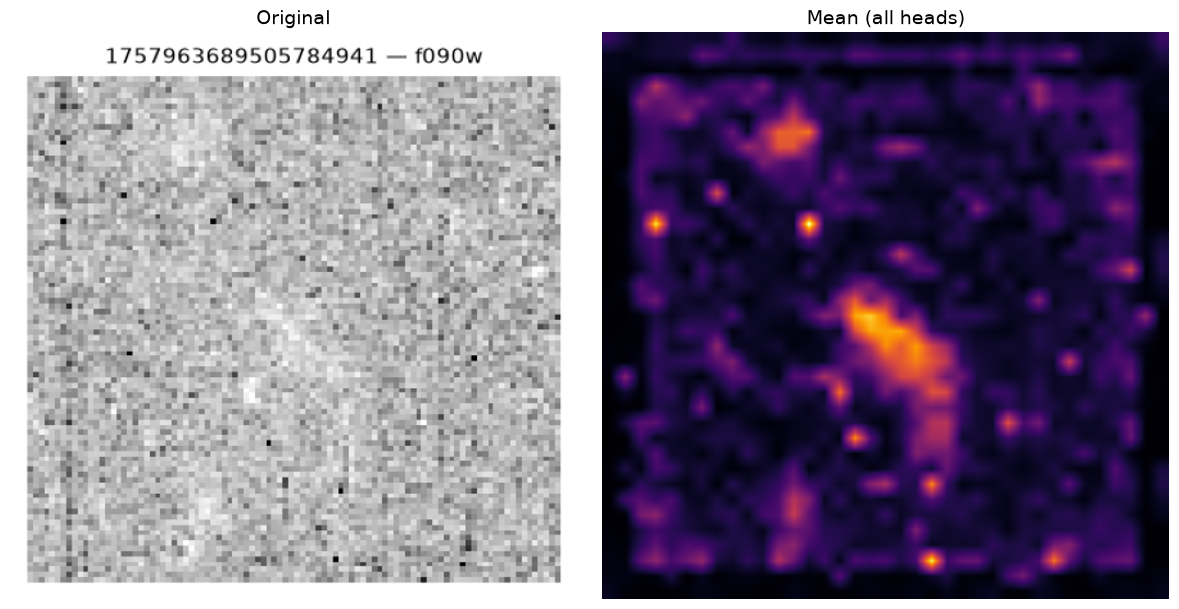

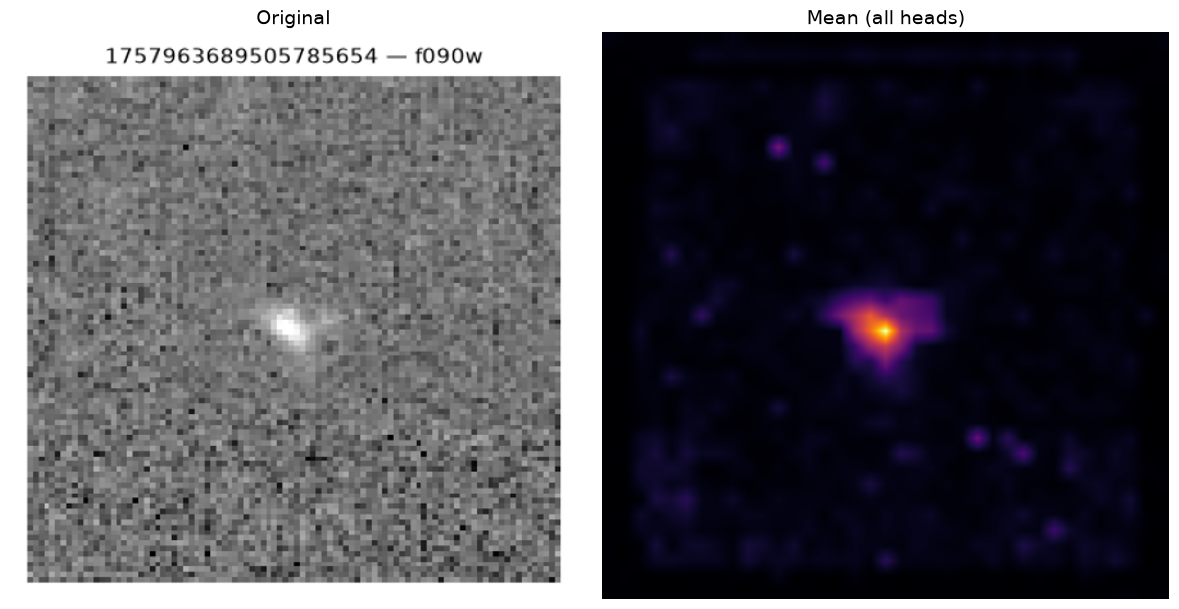

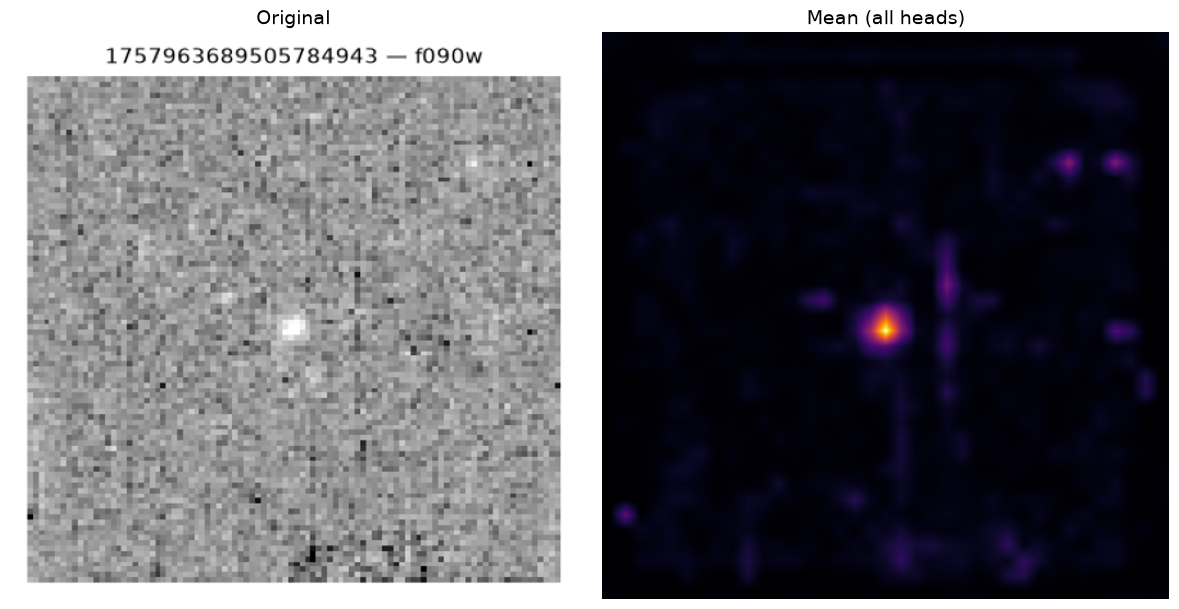

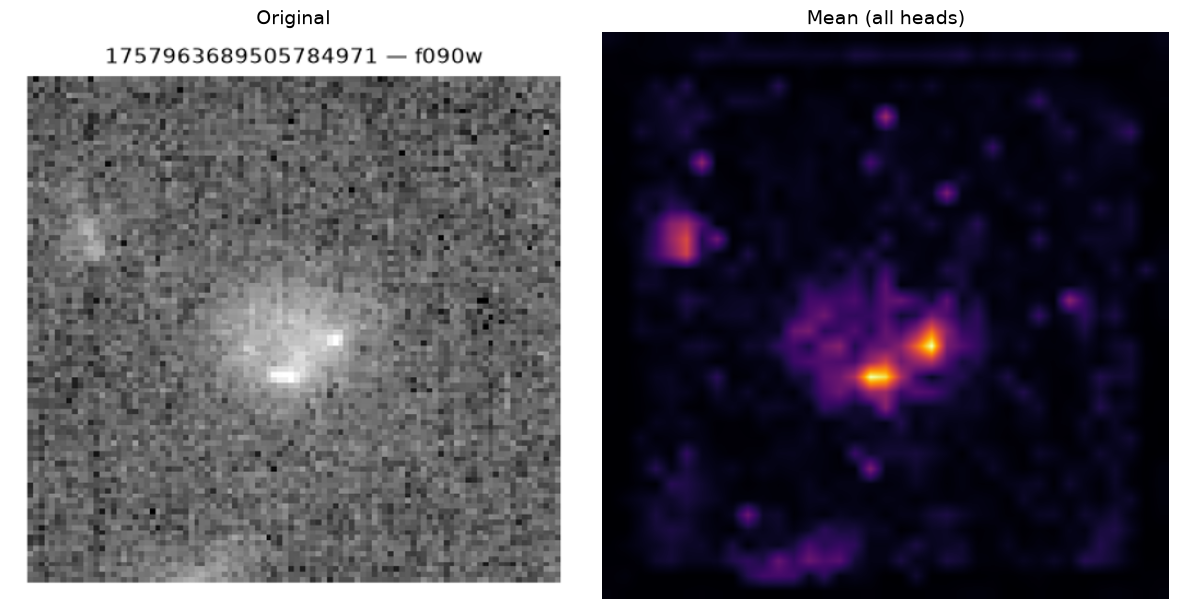

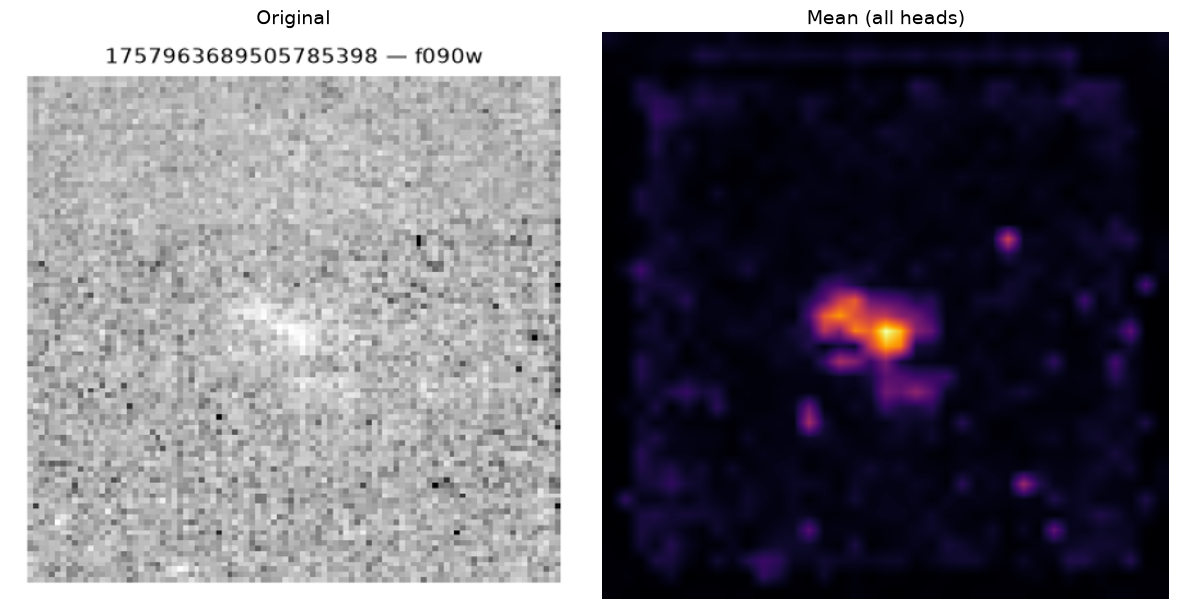

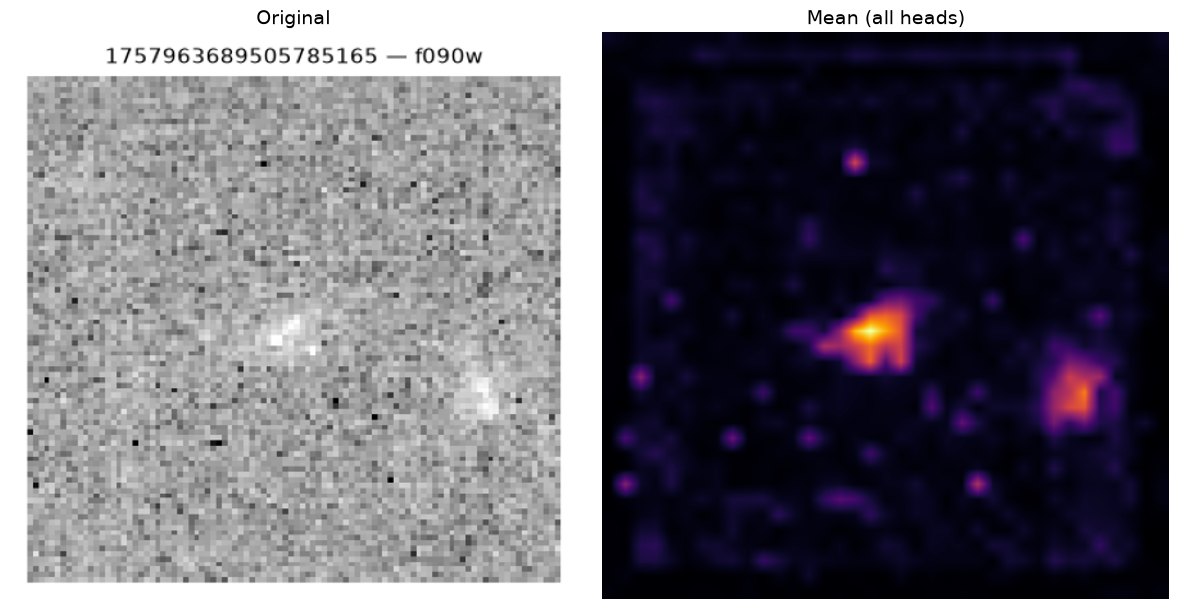

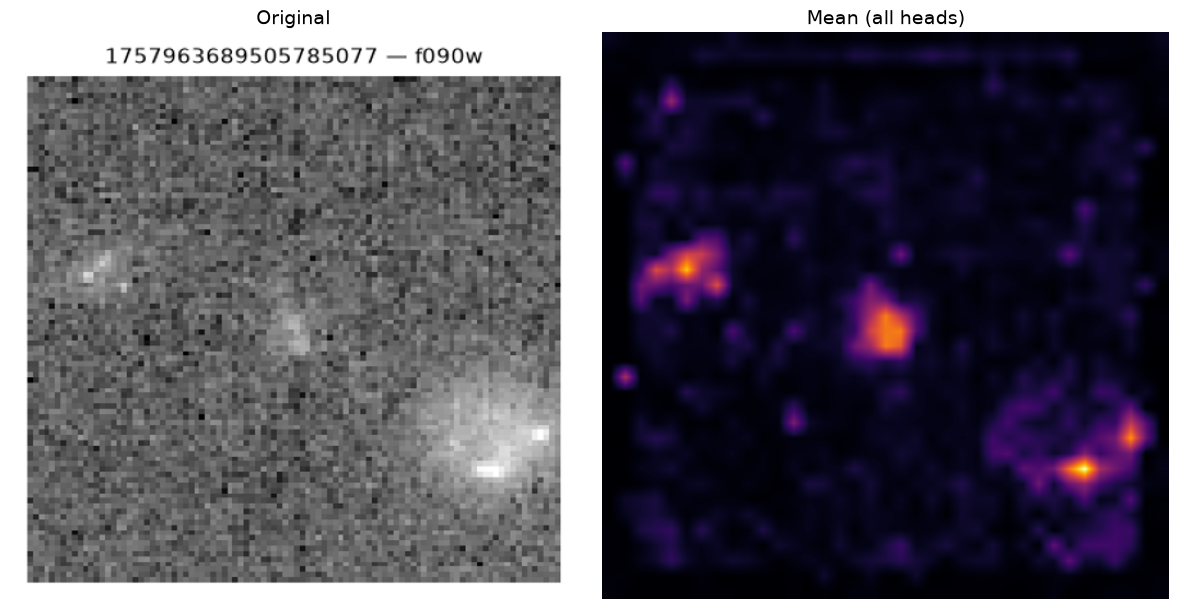

In [12]:
import os
from dino_visualizer import visualize_attention_maps

for filename in os.listdir("jwst_masked_flux"):
    visualize_attention_maps(
        'models/dinov2_vits14_reg4_pretrain.pth', 
        f'jwst_masked_flux/{filename}', 
        num_registers=4, 
        view_mode="isolated", 
        mean=True,
        output_path=f'attention_maps/{filename}'
    )

In [13]:
from astropy.visualization import make_lupton_rgb
from pathlib import Path

RGB_BANDS = {"R": "f444w", "G": "f277w", "B": "f090w"}

out_dir = Path("jwst_rgb")
out_dir.mkdir(exist_ok=True)

saved = 0
for _, row in rows:
    image_field = row["image"]
    bands = get_band_names(image_field)
    flux = to_stack(image_field["flux"])
    mask = to_mask_stack(image_field["mask"])

    channel_imgs = {}
    empty_channels = []
    for channel, band_name in RGB_BANDS.items():
        if band_name in bands:
            idx = bands.index(band_name)
            channel_imgs[channel] = np.where(mask[idx], flux[idx], 0.0)
            if not np.any(channel_imgs[channel]):
                empty_channels.append(band_name)
        else:
            channel_imgs[channel] = np.zeros((96, 96), dtype=np.float32)
            empty_channels.append(band_name)

    if empty_channels:
        print(f"{row['object_id']}: no real data in {empty_channels} — that channel will be blank")

    rgb = make_lupton_rgb(
        channel_imgs["R"], channel_imgs["G"], channel_imgs["B"],
        Q=8, stretch=0.5,
    )
    rgb = np.flipud(rgb)

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(rgb)
    ax.set_title(f"{row['object_id']} — R:f444w G:f277w B:f090w", fontsize=8)
    ax.axis("off")
    fig.savefig(out_dir / f"{row['object_id']}_rgb.png", bbox_inches="tight", dpi=120)
    plt.close(fig)
    saved += 1

print(f"saved {saved} RGB composites to {out_dir}/")

saved 7 RGB composites to jwst_rgb/


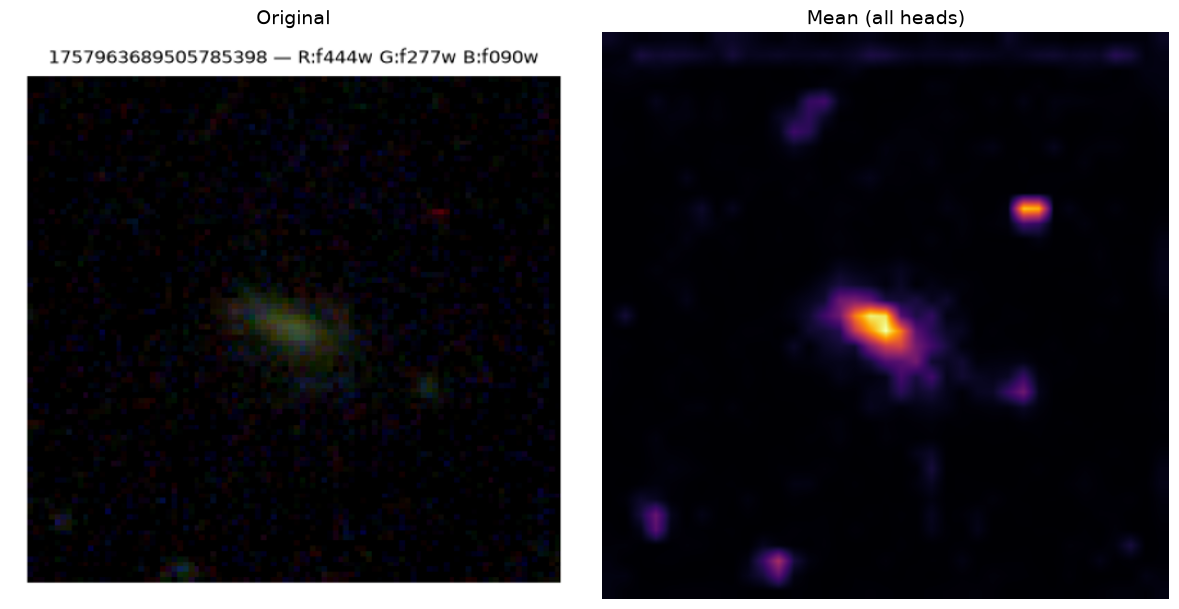

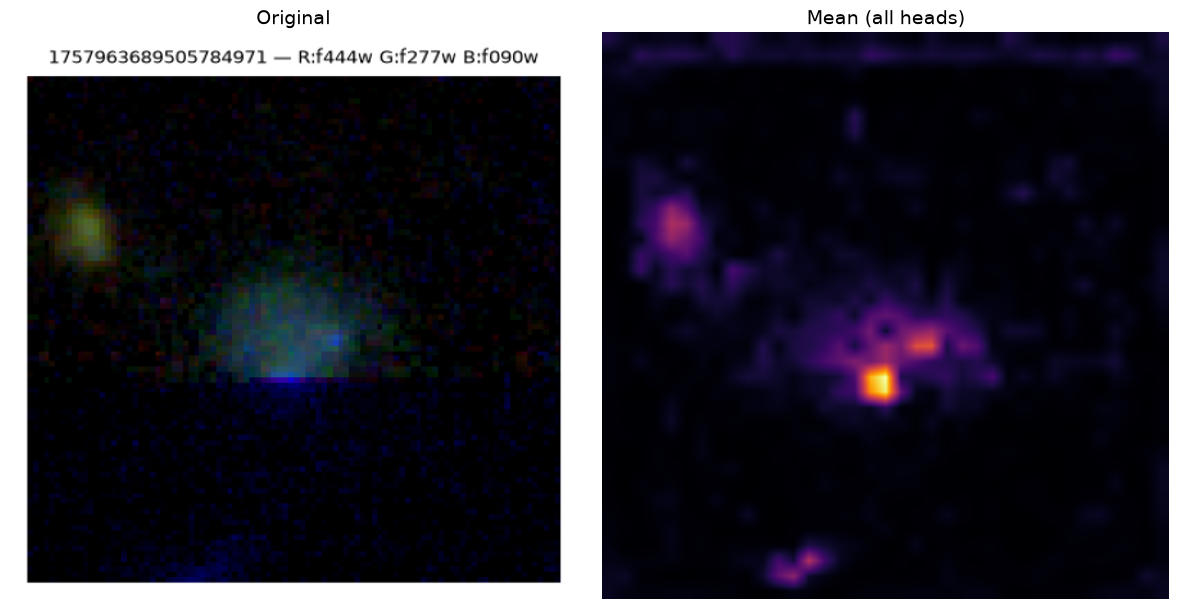

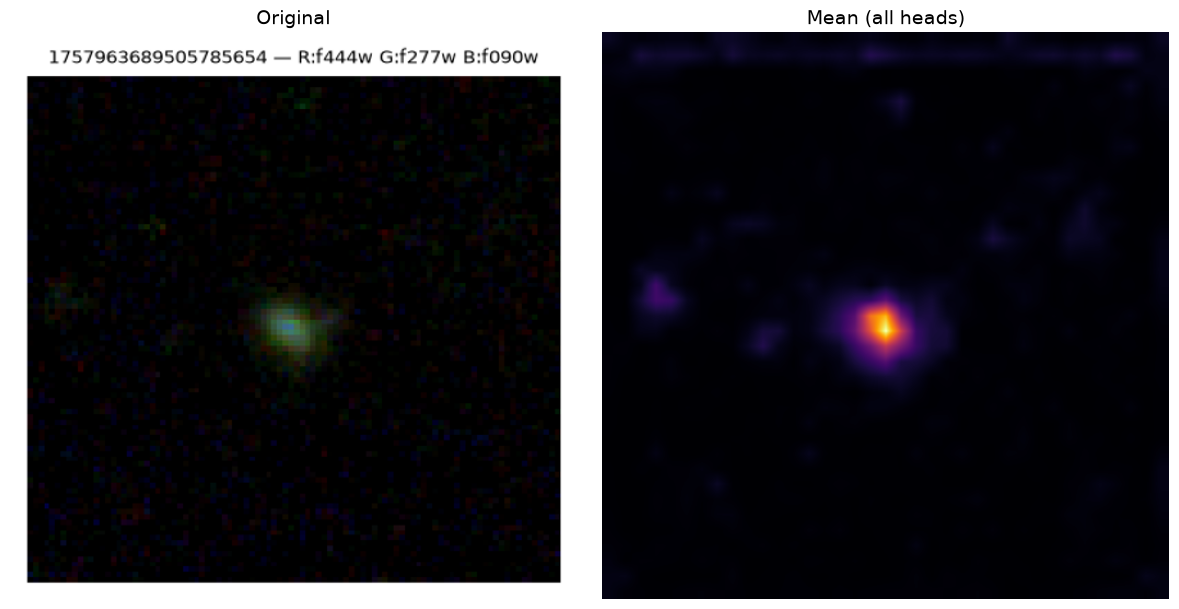

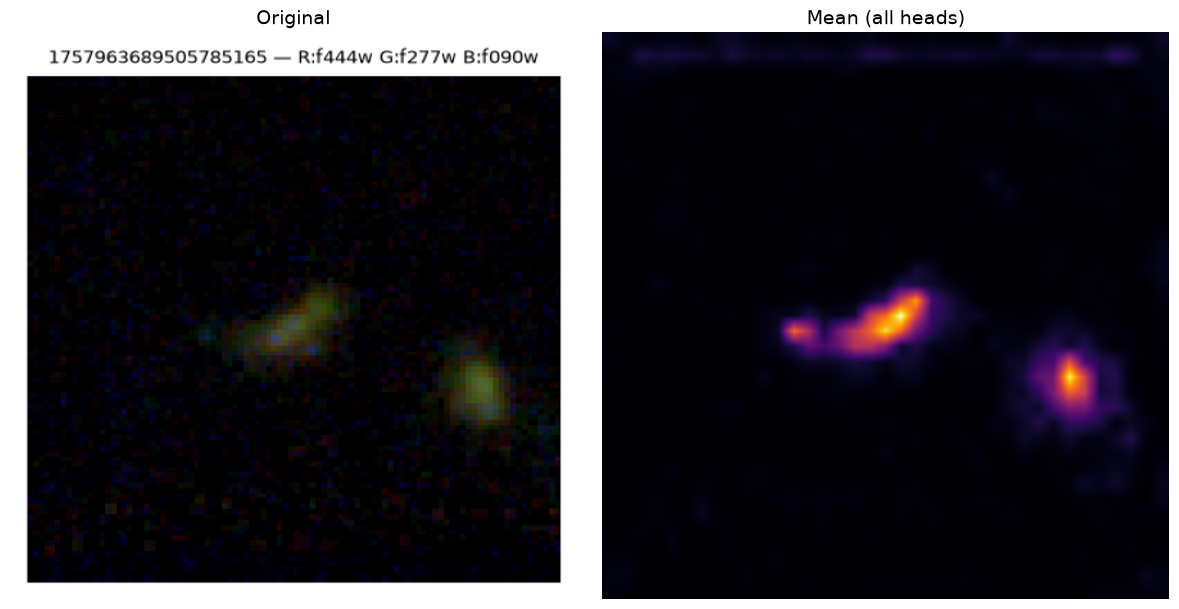

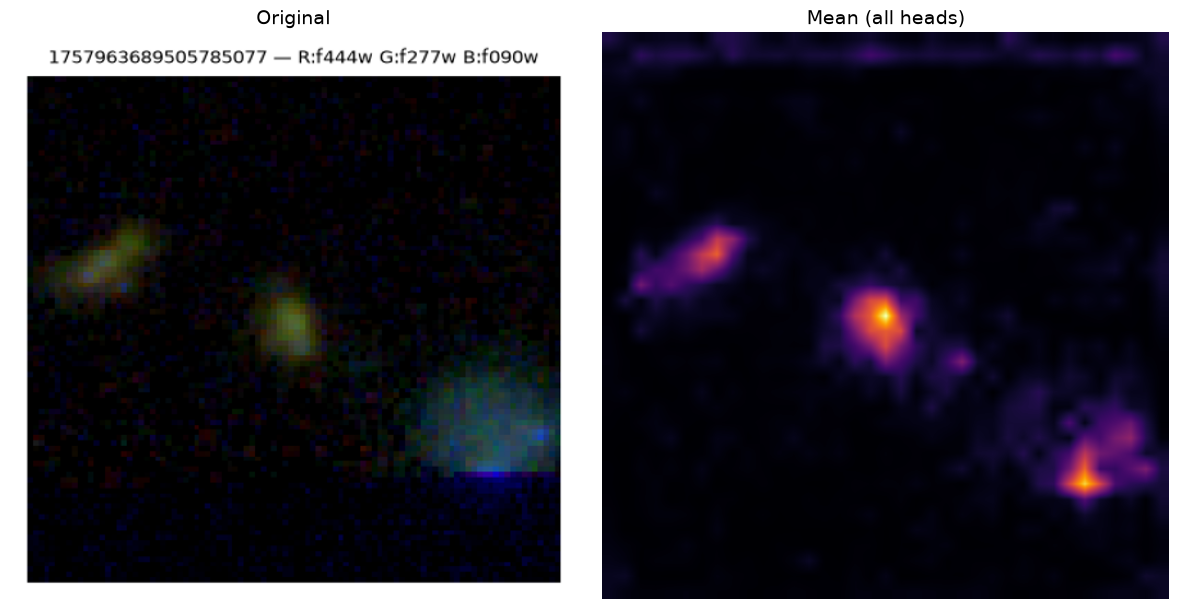

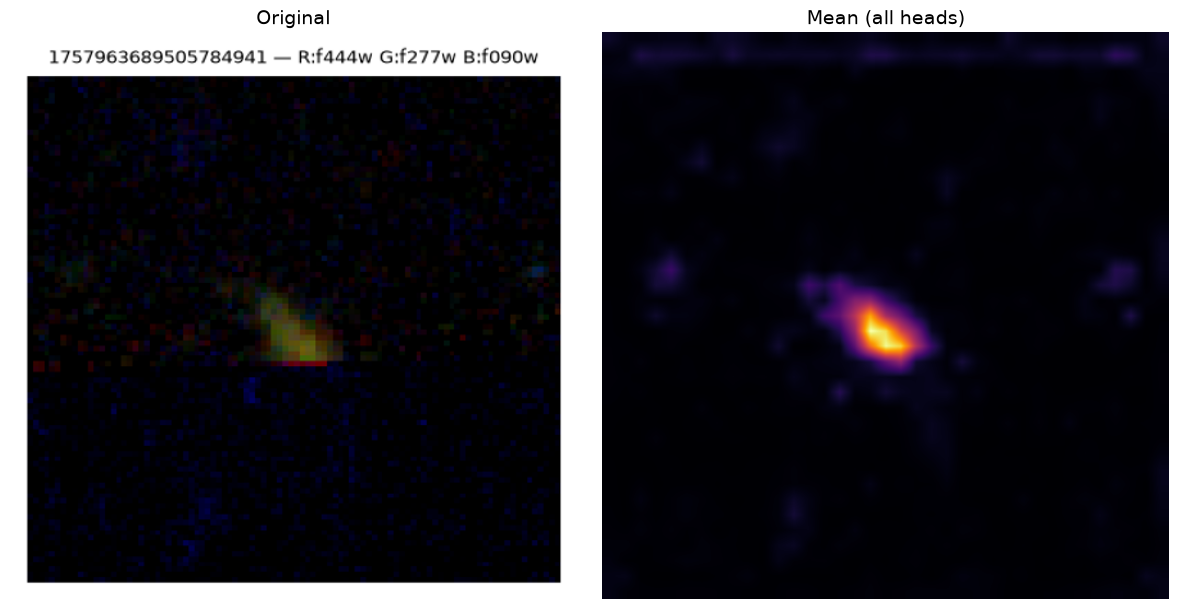

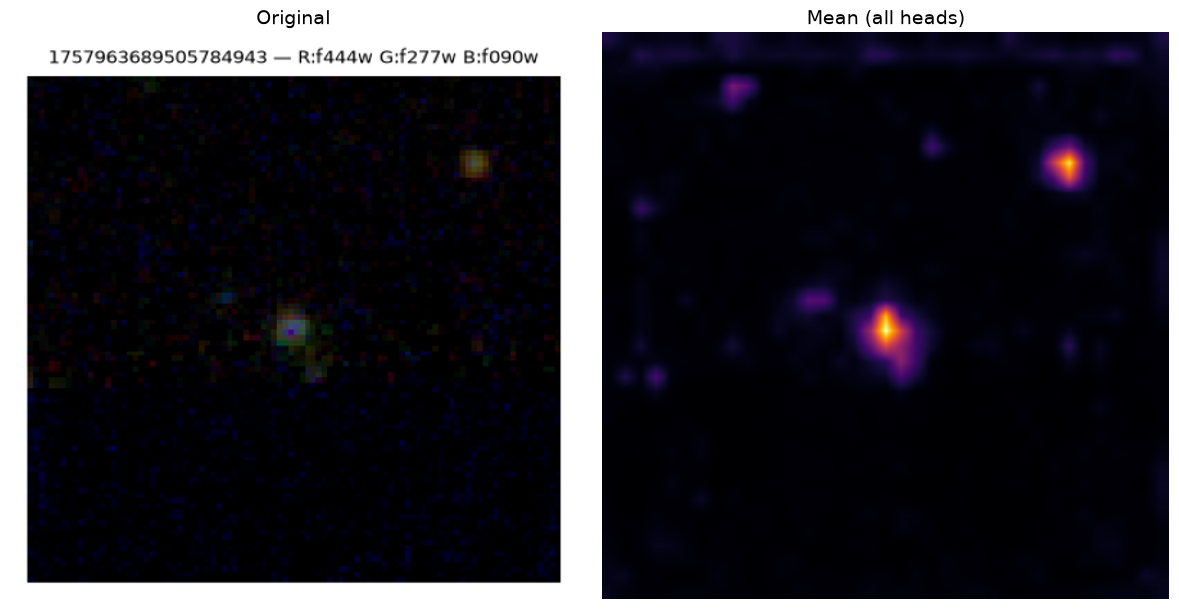

In [15]:
for filename in os.listdir("jwst_rgb"):
    visualize_attention_maps(
        'models/dinov2_vits14_reg4_pretrain.pth', 
        f'jwst_rgb/{filename}', 
        num_registers=4, 
        view_mode="isolated", 
        mean=True,
        output_path=f'attention_maps_rgb/{filename}'
    )